# Exploratory Data Analysis (EDA)

## 1. Initial Data Overview


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [52]:
df = pd.read_csv("../data/raw/telcom-customer-churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [53]:
print("The shape of the dataset is", df.shape)

The shape of the dataset is (7043, 21)


In [54]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

we got 3 numeric attributs **[SeniorCitizen, tenure, MonthlyCharges]** and the other attributes are categorical

In [55]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [56]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

- **16%** of the customers are seniors
- the average of duration that a customer stayed with the company is **32** month
- the average of charge that a customer payed to the company each month is **64.76** month

In [57]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [58]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [59]:
df.duplicated().sum()

0

- There are a lot of imbalanced attributes
- There is no missing values

In [60]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## Conclusion of Initial Data Overview

### Dataset Shape
We first check the shape of the dataset to understand:
- Number of rows (7043)
- Number of columns (21)

This gives a quick overview of dataset size and complexity.

Observation:
- The dataset contains `7043` rows and `21` columns.

---
### Columns explanation
1. `customerID` has an `object` dtype and it's an identifier to each customer
2. `gender` has an `object` dtype and it's an identifier to each sex
3. `SeniorCitizen` has an `int64` dtype and it's an identifier to each customer whether he is above '65' or not. 
    - `1` means he is 65 or older
    - `0` means he is younger than 65
4. `Partner` has an `object` dtype and it's an indication to the user having a partner or not
5. `dependents` has an `object` dtype and it's an indication to the user having people who rely on them financially or not
6. `tenure` has an `int` dtype and it's an indication to the number of months that the user stayed with the company
7. `PhoneService` has an `object` dtype and it's an indication to the customer having PhoneService or not
8. `MultipleLines`has an `object` dtype and it's an indication to the customer having MultipleLines or not even having a PhoneService
    - `yes` means he has MultipleLines
    - `No` means he hasn't MultipleLines but has a phone service
    - `No phone service` means he hasn't MultipleLines and a phone service
9. `InternetService` has an `object` dtype and it's an indication to the customer `DSL` or `Fiber optic` or `not having both`
10. `OnlineSecurity` has an `object` dtype and it's an indication to the customer having `OnlineSecurity` or not having `internet service at all`
11. `OnlineBackup` has an `object` dtype and it's an indication to the customer having `OnlineBackup` or not having `internet service at all`
12. `DeviceProtection` has an `object` dtype and it's an indication to the customer having `DeviceProtection` or not having `internet service at all`
13. `TechSupport` has an `object` dtype and it's an indication to the customer having `TechSupport` or not having `internet service at all`
14. `StreamingTV` has an `object` dtype and it's an indication to the customer having `StreamingTV` or not having `internet service at all`
15. `StreamingMovies` has an `object` dtype and it's an indication to the customer having `StreamingMovies` or not having `internet service at all`
16. `Contract` has an `object` dtype and it's an indication to the customer having `Month-to-month` or having `One year` or `Two year` contract
17. `PaperlessBilling` has an `object` dtype and it's an indication to the customer getting the bills via `email` or `mail`
18. `PaymentMethod` has an `object` dtype and it's an indication to the customer method of paying 
19. `MonthlyCharges` has an `float64` dtype and it's an indication to how much does the customer pays per month
20. `TotalCharges` has an `object` dtype and it's an indication to how much does the customer pays 
21. `Churn` has an `object` dtype and it's an indication to Whether the customer churned

## 2. Data Cleaning 

In [61]:
# convert the `TotalCharges` column to float
try:    
    pd.to_numeric(df["TotalCharges"])
except ValueError:
    print('Unable to parse string " "')

Unable to parse string " "


In [62]:
df[df["TotalCharges"]== " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


- in the column `TotalCharges` there are **11** with the value `" "`, and have in common that the `tenure = 0`. 

    - this can make us put the values inside the `MonthlyCharges` in `TotalCharges` because most likely these customers 've been billed but the cycle hasn't ended

In [63]:
df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', pd.NA, regex=True).fillna(df['MonthlyCharges'])


now, we can convert the column from `object` to `float`.

In [64]:
df['TotalCharges'] = df['TotalCharges'].astype(float)


## 3. Univariate Analysis 

In [65]:
# convert `SeniorCitizen` column to be type object
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'}).astype('category')

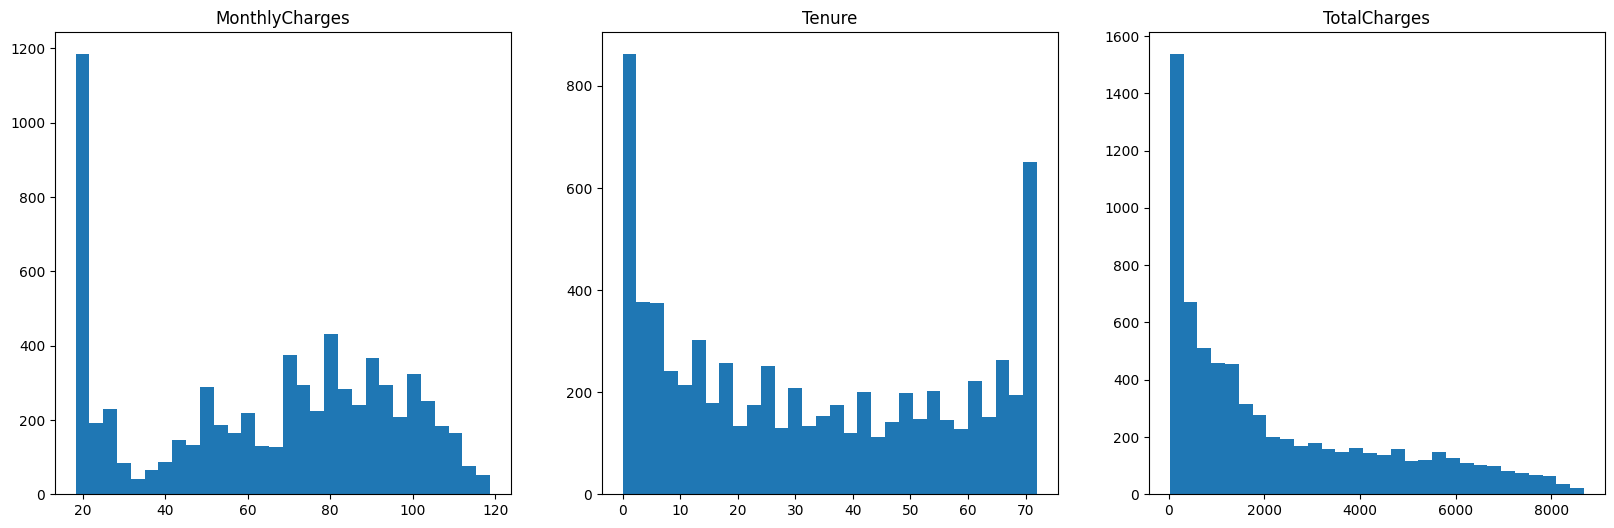

In [66]:
fig, ax = plt.subplots(1, 3, figsize=(20,6))

ax[0].hist(df["MonthlyCharges"], bins=30)
ax[0].set_title("MonthlyCharges")

ax[1].hist(df["tenure"], bins=30)
ax[1].set_title("Tenure")

ax[2].hist(df["TotalCharges"], bins=30)
ax[2].set_title("TotalCharges")
plt.show()

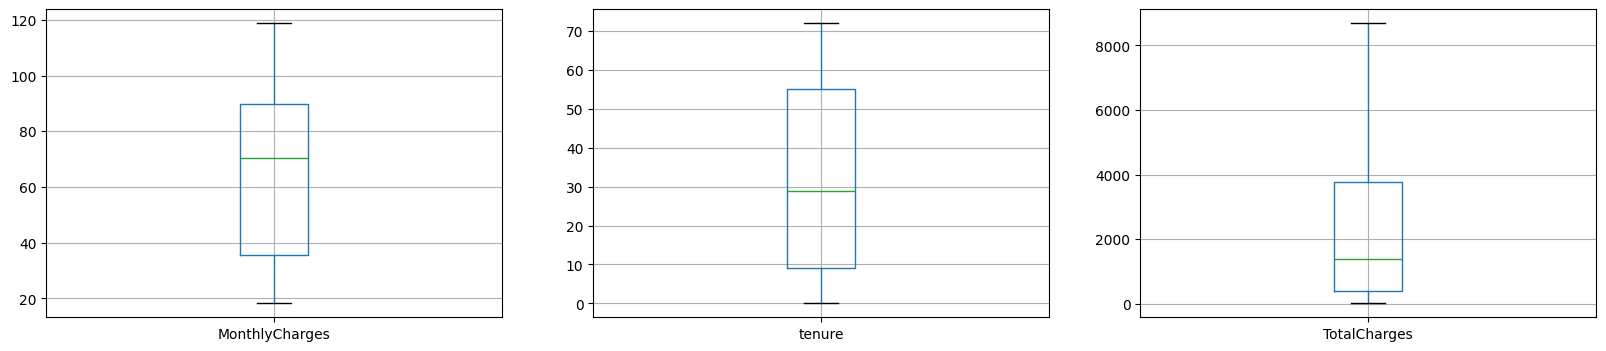

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4))
df.boxplot(column='MonthlyCharges', ax=axes[0])
df.boxplot(column='tenure', ax=axes[1])
df.boxplot(column='TotalCharges', ax=axes[2])
plt.show()

### From the histograms we get:
- `MonthlyCharges`: Bimodal, Most of the customers on the basic plan (~20$) and also there are around 70$ and 80$
- `tenure`: U-shaped, indicate that most of the customer are new or a very loyal
- `TotalCharges`: Skewed to right needs a log-transform
### From boxplot we get:
- No outliers in the numeric data
- `tenure`, and `MonthlyCharges` got a wide IQR, which means a higher variance.


## 4. Bivariate Analysis

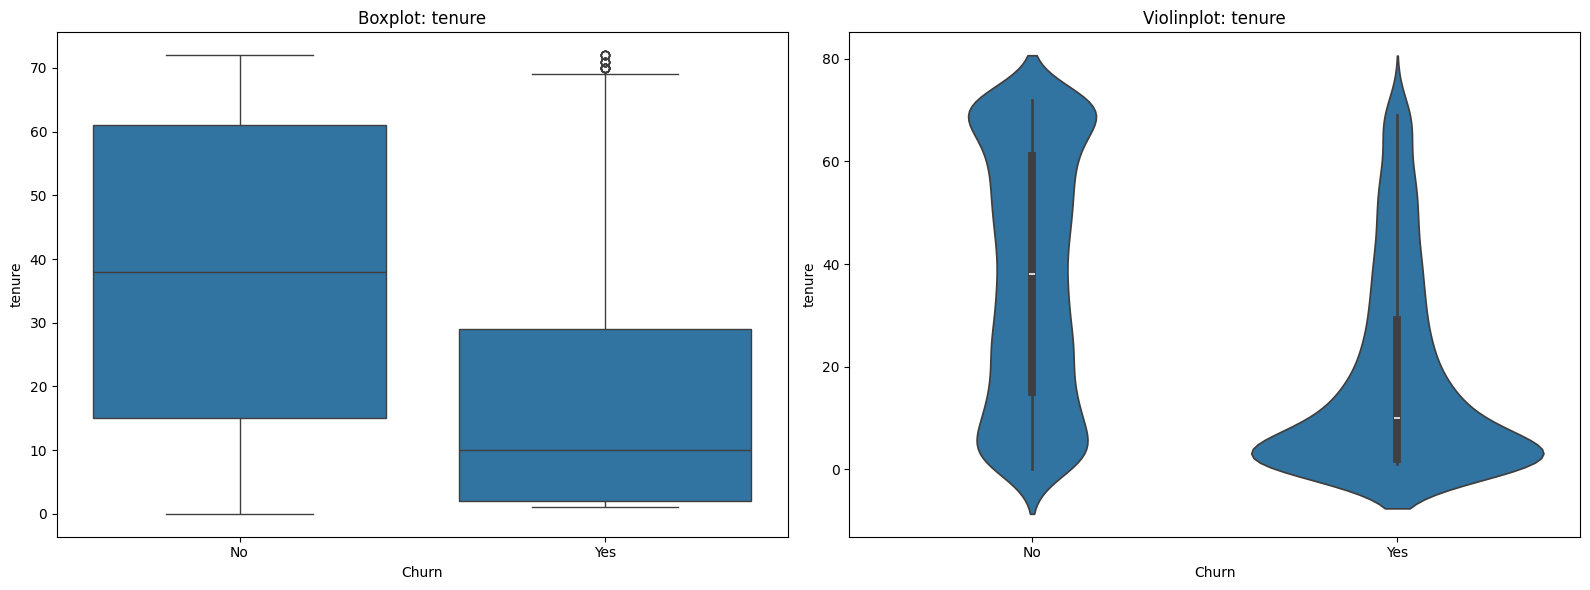

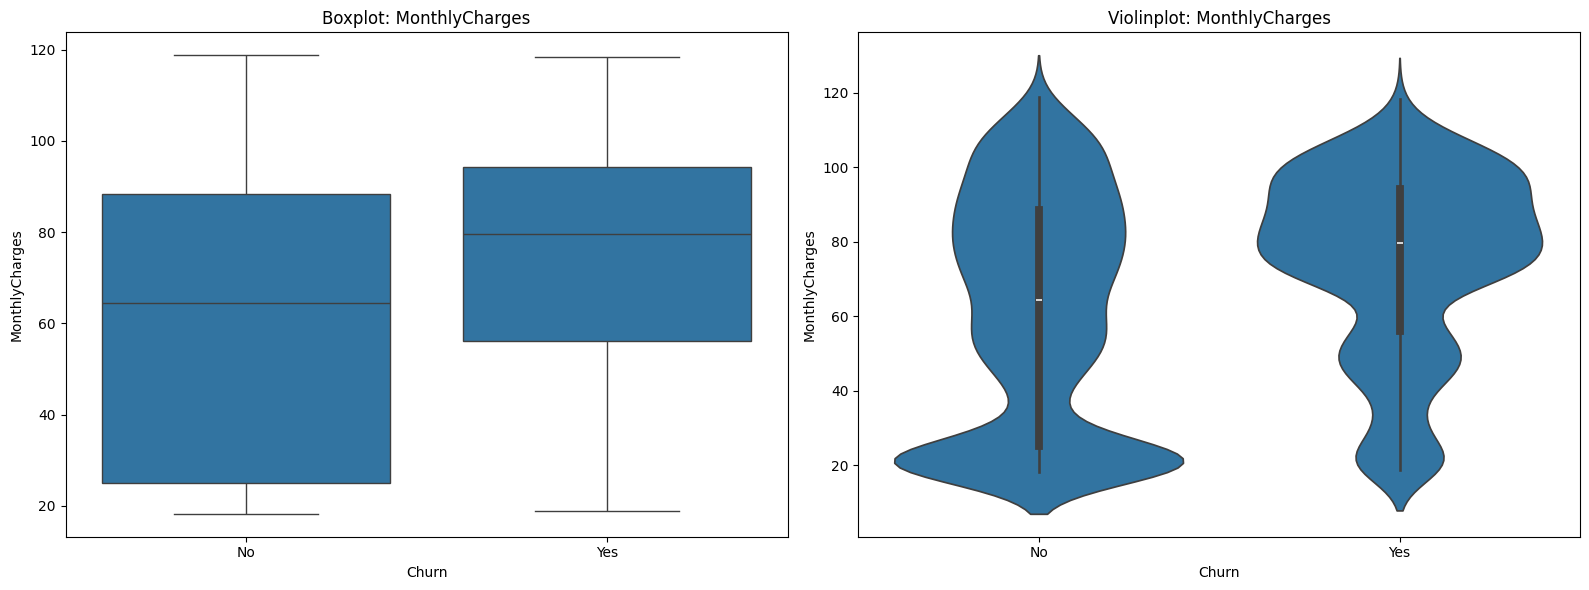

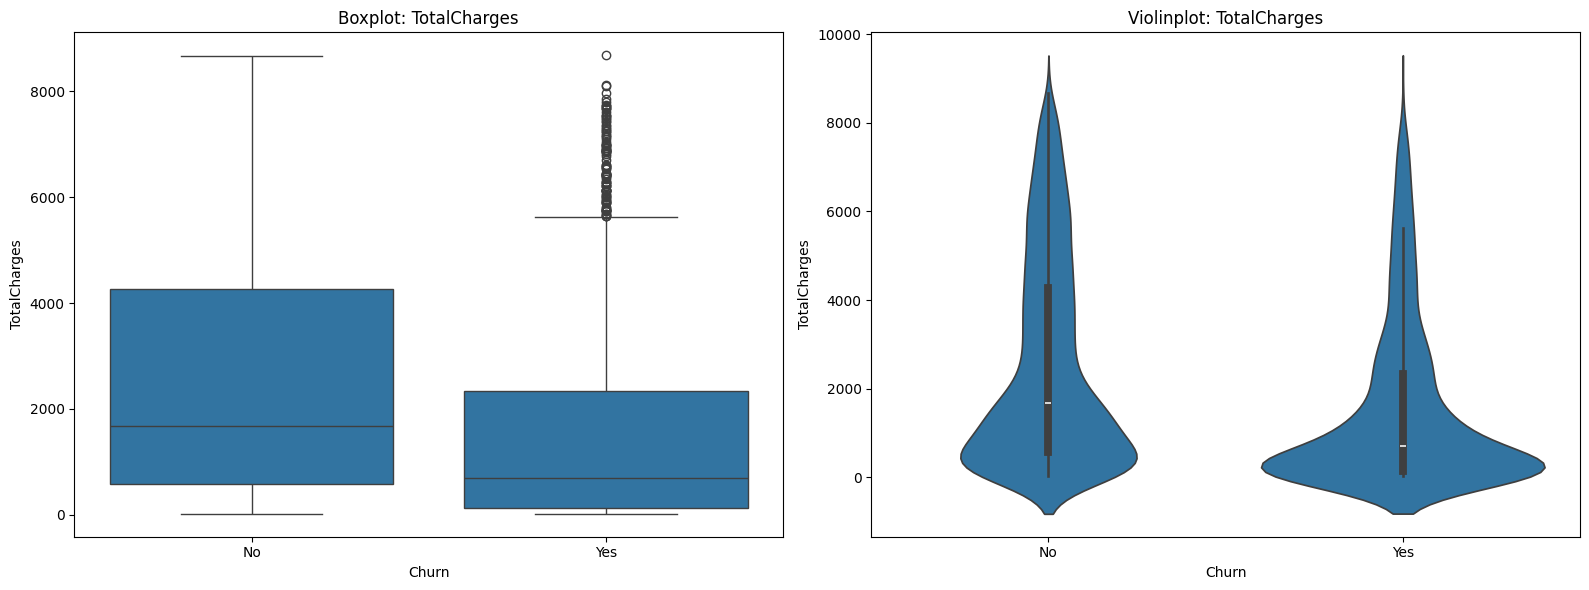

In [68]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[0])
    axes[0].set_title(f'Boxplot: {col}')
    sns.violinplot(x='Churn', y=col, data=df, ax=axes[1])
    axes[1].set_title(f'Violinplot: {col}')
    plt.tight_layout()
    plt.show()

In [69]:
df.drop('customerID', axis=1, inplace=True)

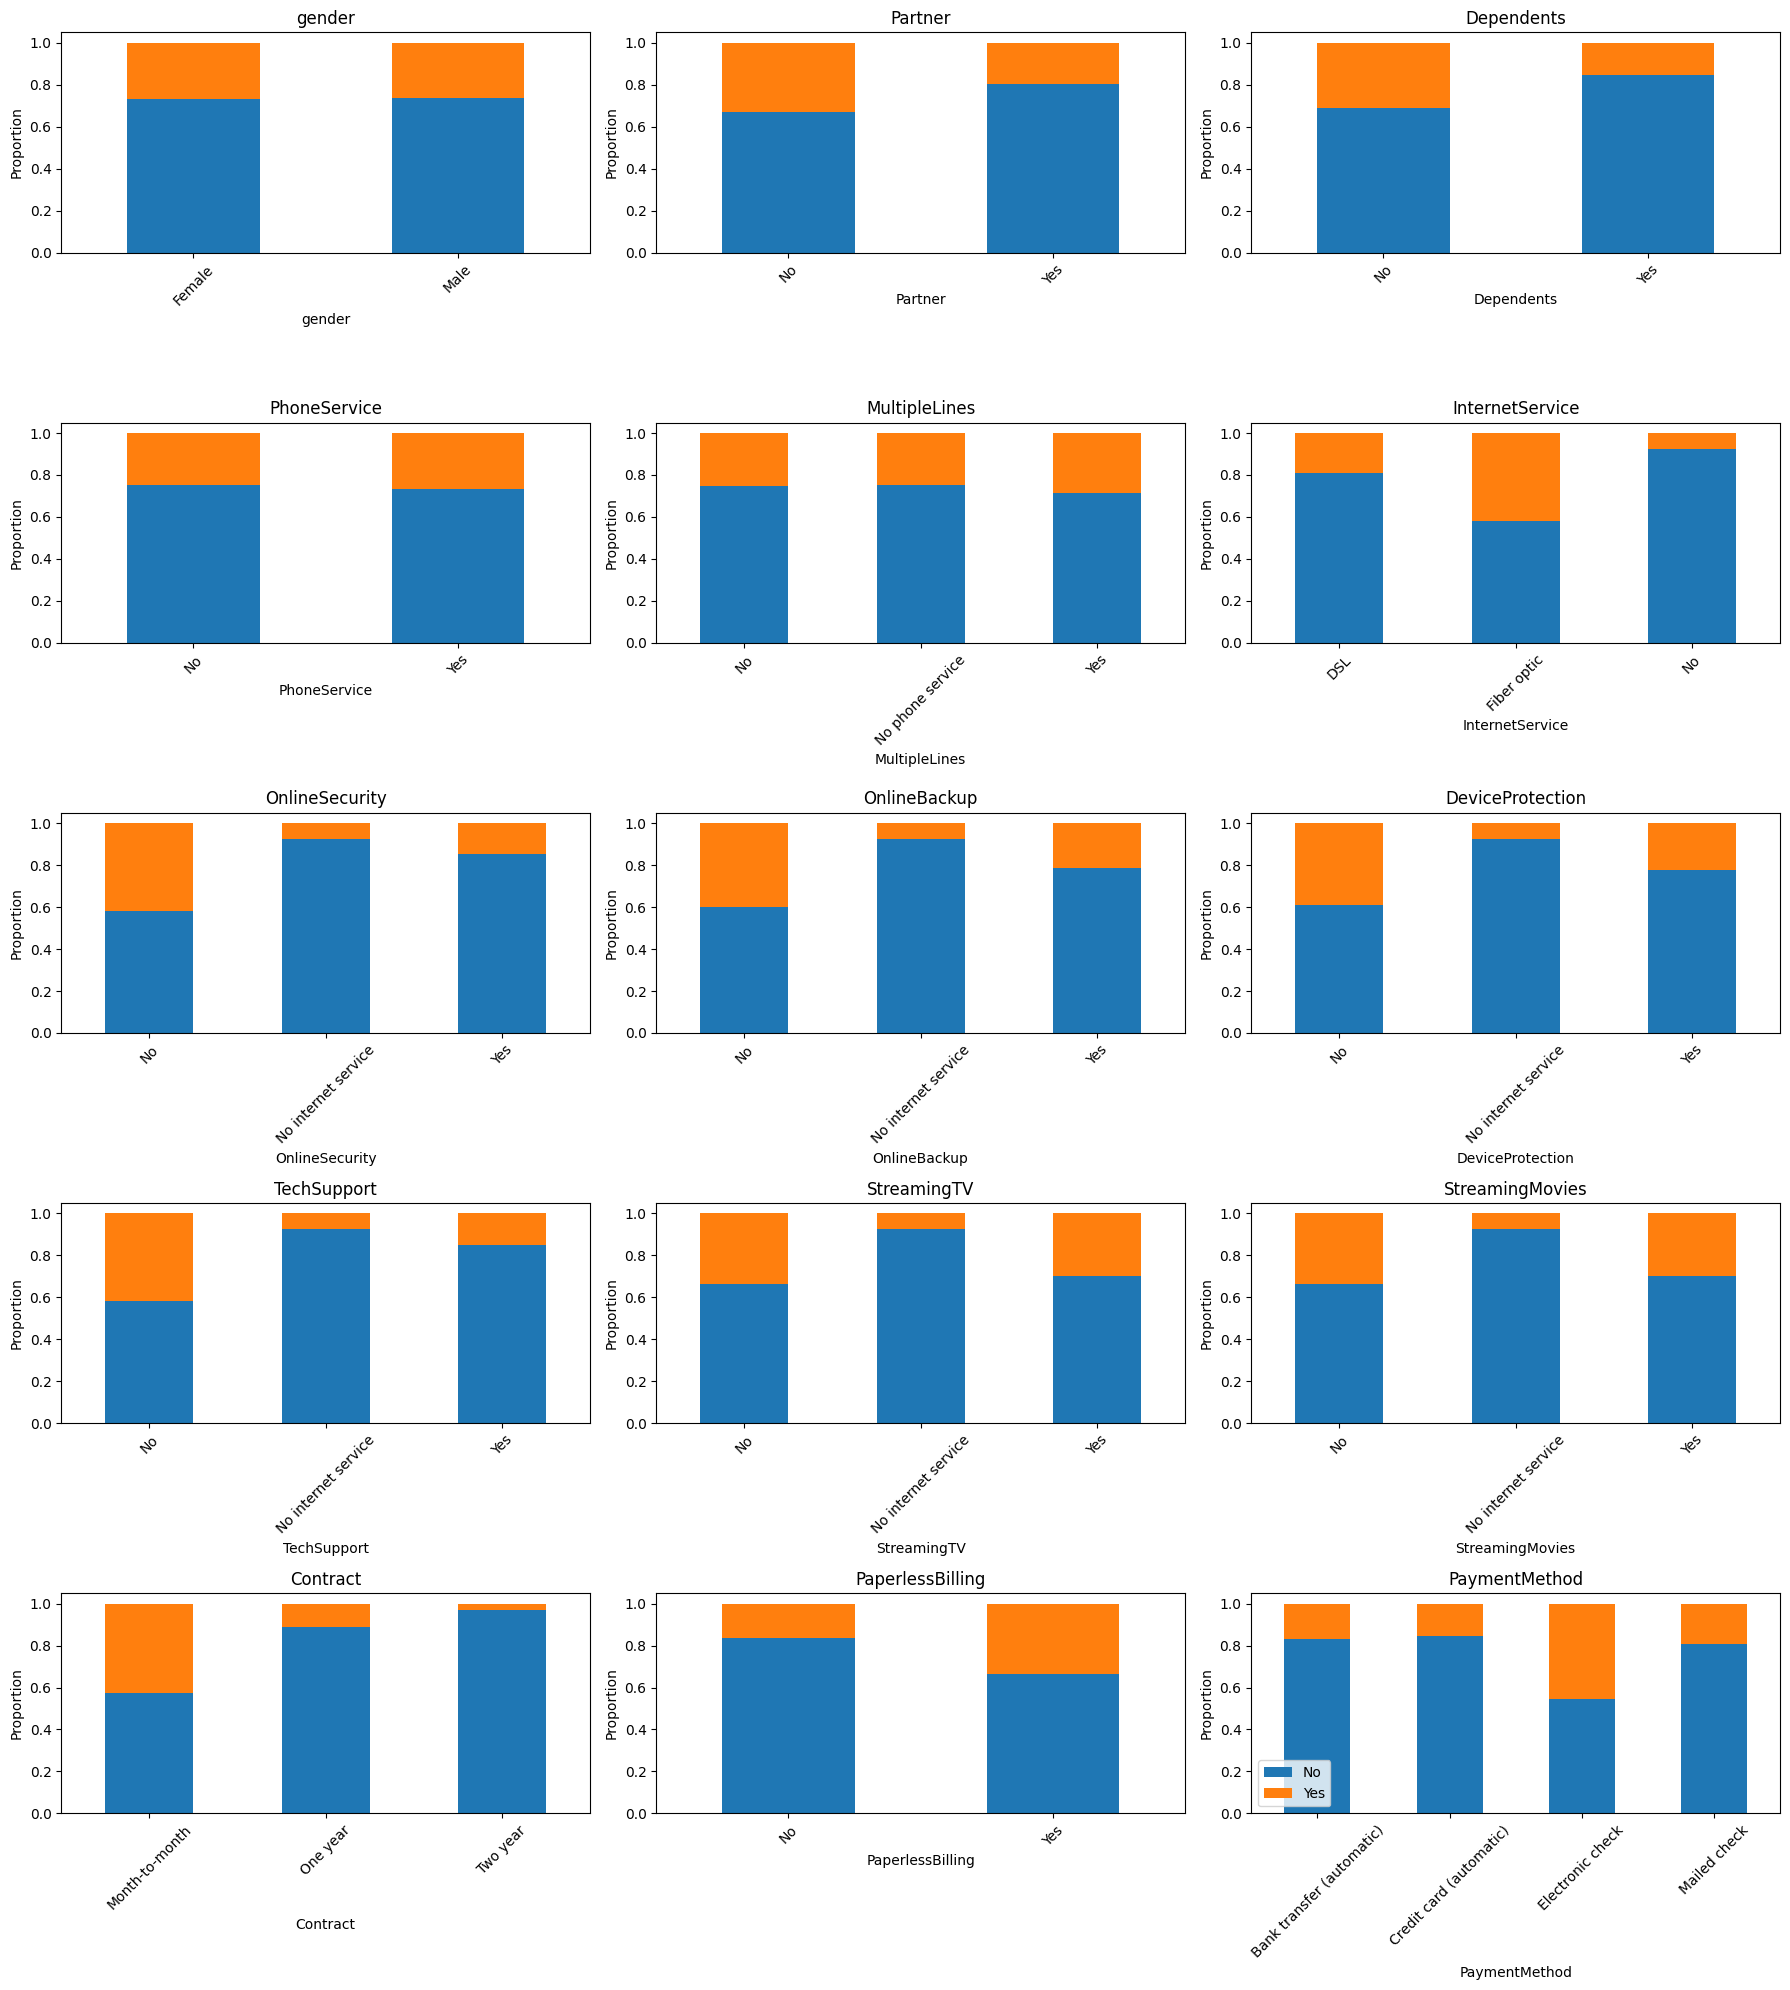

In [70]:
import math

cat_cols = df.select_dtypes(include='object').columns.drop('Churn')
n = len(cat_cols)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(18, 4*rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    pd.crosstab(df[col], df['Churn'], normalize='index').plot(
        kind='bar', stacked=True, ax=axes[i], legend=False)
    axes[i].set_title(col)
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=45)

# hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.legend()
plt.show()

In [71]:
churn_rate = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean())
churn_rate

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

In [72]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    return np.sqrt(chi2 / (n * (min(confusion.shape) - 1)))

for col in cat_cols:
    print(f"{col}: {cramers_v(df[col], df['Churn']):.3f}")

gender: 0.008
Partner: 0.150
Dependents: 0.164
PhoneService: 0.011
MultipleLines: 0.040
InternetService: 0.322
OnlineSecurity: 0.347
OnlineBackup: 0.292
DeviceProtection: 0.282
TechSupport: 0.343
StreamingTV: 0.231
StreamingMovies: 0.231
Contract: 0.410
PaperlessBilling: 0.191
PaymentMethod: 0.303


In [73]:
# Outliers in Yes group only
yes = df[df['Churn']=='Yes']['tenure']
Q1, Q3 = yes.quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = yes[(yes < Q1 - 1.5*IQR) | (yes > Q3 + 1.5*IQR)]
print(outliers.describe())

count    23.000000
mean     70.782609
std       0.850482
min      70.000000
25%      70.000000
50%      71.000000
75%      71.500000
max      72.000000
Name: tenure, dtype: float64


## 5. Multivariate Analysis

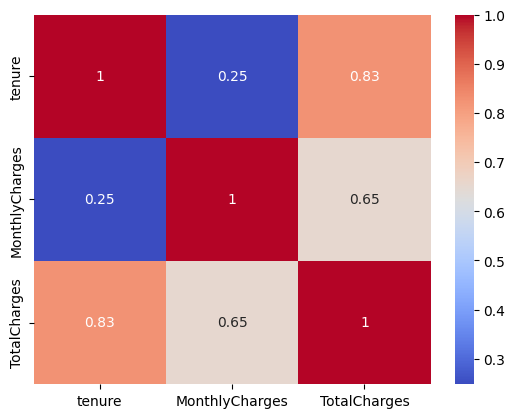

In [74]:
df.select_dtypes(include='number').corr()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm');

## EDA Summary

### Dataset
- 7043 rows, 21 column
- Label Churn (73.4% No, 26.4% Yes — imbalanced)
- Total charges miss 11 values - Imputed
- No outliers or duplicates

### Strong predictors
- **tenure**: churners don't spend that much time with the company
- **Contract**: month-to-month customers tends to churn more than two-year and one-year plan
- **OnlineSecurity, TechSupport**: No service —> High Churn
- **Payment method**: Customers who pays with electronic check churn more.

### Weak / dropped
- **gender**: Not giving anything new. (~27% both) → dropped
- **PhoneService**: minimal difference → dropped

### Relationships noticed
- tenure ↑ → churn ↓
- MonthlyCharges ↑ → churn ↑
- TotalCharges ≈ tenure × MonthlyCharges (collinear — keep tenure and drop TotalCharges)
- Customers without services, churn more

### Decisions for modeling
- Drop: gender, customerID, (one of TotalCharges/tenure)
- Encode: one-hot for nominal, binary map for yes/no
- Scale: MonthlyCharges, tenure (different ranges)
- Handle imbalance: class_weight or SMOTE after test a base model without them